# 12 - The backward kernel: a minimal diff-gaussian-rasterization

Notebook 11 renders fast and learns nothing: the kernels compute an
image and keep no record of how, so training is still notebook 09's
dense autograd forward, priced below, live, in milliseconds per
iteration. With rendering solved, that price is now almost entirely the
backward pass and the dense bookkeeping autograd keeps to make it
possible. This notebook removes the last slow piece: a CUDA backward
for the tiled rasterizer, so the whole training loop runs at kernel
speed. The result is a minimal `diff-gaussian-rasterization`, the
component the official 3DGS trainer is built around.

Nothing new is derived here. Notebook 08 derived the backward through
the over operator and checked it against finite differences; the kernel
below is that derivation transcribed into the tile walk of notebook 11,
run in reverse. The chain from conic and 2D mean back to quaternions,
scales, and 3D means stays in torch autograd on the host, exactly where
notebook 09 built and gradchecked it. The official implementation fuses
that chain into its kernels too (`computeCov2DCUDA` is its name for the
projection backward); the boundary is theirs to move for speed, ours to
keep for clarity, and the gradients agree either way.

Needs an NVIDIA GPU + CUDA toolkit + ninja; without them the GPU cells
skip with a message and the host-side checks still run.

In [1]:
import time
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import torch
from gsplat_edu import Camera, render_gaussians, sphere_shell

torch.manual_seed(12)
ROOT = pathlib.Path(".").resolve()

DILATION = 0.3
ALPHA_MIN = 1.0 / 255
ALPHA_MAX = 0.99
T_STOP = 1e-4
Z_NEAR = 0.05
C0 = 0.28209479177387814
TILE = 16
SIZE, FX = 128, 150.0
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HAS_GPU = torch.cuda.is_available()
print("CUDA device:" if HAS_GPU else "No CUDA device -",
      torch.cuda.get_device_name(0) if HAS_GPU
      else "GPU cells skip; the notebook keeps its CPU-side checks.")

CUDA device: NVIDIA GeForce RTX 5080


## The dense forward, restated, and its live price

Notebook 09's renderer, verbatim: it is both the baseline to beat and
the reference the kernel's gradients must match.

In [2]:
def quat_to_R_t(q):
    q = q / q.norm(dim=-1, keepdim=True)
    w, x, y, z = q.unbind(-1)
    return torch.stack([
        torch.stack([1 - 2 * (y * y + z * z), 2 * (x * y - w * z),
                     2 * (x * z + w * y)], -1),
        torch.stack([2 * (x * y + w * z), 1 - 2 * (x * x + z * z),
                     2 * (y * z - w * x)], -1),
        torch.stack([2 * (x * z - w * y), 2 * (y * z + w * x),
                     1 - 2 * (x * x + y * y)], -1)], -2)

def cov3d_t(log_s, quats):
    M = quat_to_R_t(quats) * torch.exp(log_s)[..., None, :]
    return M @ M.mT

def render_dense(means, cov3ds, colors, opacities, cam, chunk=512):
    """Notebook 09's dense differentiable forward (bbox-free, T_STOP-free)."""
    dev, dt = means.device, means.dtype
    R = torch.tensor(cam.R, dtype=dt, device=dev)
    eye = torch.tensor(cam.eye, dtype=dt, device=dev)
    Pc = (means - eye) @ R.T
    vis = Pc[:, 2] > Z_NEAR
    Pc, cov3ds = Pc[vis], cov3ds[vis]
    colors, opacities = colors[vis], opacities[vis]
    order = torch.argsort(Pc[:, 2])
    Pc, cov3ds = Pc[order], cov3ds[order]
    colors, opacities = colors[order], opacities[order]
    x, y, z = Pc.unbind(-1)
    u = cam.fx * x / z + cam.cx
    v = cam.fy * y / z + cam.cy
    zero = torch.zeros_like(z)
    J = torch.stack([
        torch.stack([cam.fx / z, zero, -cam.fx * x / z ** 2], -1),
        torch.stack([zero, cam.fy / z, -cam.fy * y / z ** 2], -1)], -2)
    T_JW = J @ R
    S2 = T_JW @ cov3ds @ T_JW.mT
    a = S2[:, 0, 0] + DILATION
    c = S2[:, 1, 1] + DILATION
    b = S2[:, 0, 1]
    det = a * c - b * b
    A00, A01, A11 = c / det, -b / det, a / det
    ys = torch.arange(cam.H, dtype=dt, device=dev)
    xs = torch.arange(cam.W, dtype=dt, device=dev)
    img = torch.zeros(cam.H, cam.W, 3, dtype=dt, device=dev)
    T_run = torch.ones(cam.H, cam.W, dtype=dt, device=dev)
    for k0 in range(0, len(u), chunk):
        k1 = min(k0 + chunk, len(u))
        dx = xs[None, None, :] - u[k0:k1, None, None]
        dy = ys[None, :, None] - v[k0:k1, None, None]
        power = (-0.5 * (A00[k0:k1, None, None] * dx * dx
                         + A11[k0:k1, None, None] * dy * dy)
                 - A01[k0:k1, None, None] * dx * dy)
        alpha = opacities[k0:k1, None, None] * torch.exp(power)
        alpha = torch.clamp(alpha, max=ALPHA_MAX)
        alpha = torch.where(alpha < ALPHA_MIN, torch.zeros_like(alpha), alpha)
        Tc = torch.cumprod(1.0 - alpha, dim=0)
        T_before = torch.cat([T_run[None], T_run * Tc[:-1]], dim=0)
        img = img + torch.einsum("khw,kc->hwc", T_before * alpha,
                                 colors[k0:k1])
        T_run = T_run * Tc[-1]
    return img

cam0 = Camera.looking_at(eye=[0, 0, -3], target=[0, 0, 0],
                         fx=FX, fy=FX, H=SIZE, W=SIZE)
gen = torch.Generator().manual_seed(12)
K_PROBE = 400
probe = {
    "means": (torch.randn(K_PROBE, 3, generator=gen) * 0.5).requires_grad_(),
    # scales must differ per axis: with isotropic scales Sigma = s^2 I no
    # matter the quaternion, and the quat gradcheck below compares noise
    "log_s": (float(np.log(0.09))
              + 0.3 * torch.randn(K_PROBE, 3, generator=gen)).requires_grad_(),
    "quats": (torch.tensor([[1.0, 0, 0, 0]] * K_PROBE)
              + 0.1 * torch.randn(K_PROBE, 4, generator=gen)).requires_grad_(),
    "sh0": (0.3 * torch.randn(K_PROBE, 3, generator=gen)).requires_grad_(),
    "o_logit": torch.full((K_PROBE,), -1.0).requires_grad_(),
}
target_probe = torch.rand(SIZE, SIZE, 3, generator=gen)

def dense_step():
    img = render_dense(probe["means"], cov3d_t(probe["log_s"], probe["quats"]),
                       torch.clamp(C0 * probe["sh0"] + 0.5, min=0.0),
                       torch.sigmoid(probe["o_logit"]), cam0)
    loss = (img - target_probe).abs().mean()
    loss.backward()
    for p in probe.values():
        p.grad = None

dense_step()                                  # warm up
t0 = time.perf_counter()
for _ in range(3):
    dense_step()
t_dense_cpu = (time.perf_counter() - t0) / 3
print(f"dense torch forward+backward, CPU, K={K_PROBE} at {SIZE} px: "
      f"{t_dense_cpu * 1e3:.0f} ms/iter")

dense torch forward+backward, CPU, K=400 at 128 px: 55 ms/iter


## What the forward must remember

Notebook 08 reconstructed every per-pixel transmittance from the end
state: keep `T_final`, walk splats back to front, divide out
`(1 - alpha_i)` as you go, and maintain the suffix of color blended
behind the current splat. The 0.99 alpha cap installed in notebook 05
is what makes the division safe. A tile-parallel version needs one more
number per pixel: how far into the tile's list the forward actually
got before `T_STOP` retired the pixel, so the backward walk knows where
each pixel's history ends. So the forward kernel in
`cuda/backward/diff_raster.cu` is notebook 11's, storing two extras per
pixel: final transmittance and the last-contributor count.

The backward kernel is the same tile walk run in reverse: shared-memory
batches from the back of the list, and per splat

$$T \leftarrow \frac{T}{1 - \alpha}
\qquad\text{recover } T_i \text{ (notebook 08)}$$

$$\frac{\partial L}{\partial c_i}
= \frac{\partial L}{\partial C} \, \alpha \, T$$

$$\frac{\partial L}{\partial \alpha_i}
= \frac{\partial L}{\partial C} \cdot
\left(c_i T - \frac{S}{1 - \alpha}\right)$$

$$S \mathrel{+}= c_i \alpha T
\qquad\text{suffix behind the next splat}$$

then through the kernel to opacity, 2D mean, and conic, with the two
gates notebook 08 established: a splat clamped at 0.99 or cut by the
alpha floor contributes no kernel gradient. One pixel writes gradients
for many splats and one splat hears from many pixels, so the per-splat
sums go through `atomicAdd`, same as the official implementation.

## The autograd boundary

The kernel returns gradients for exactly its four inputs: 2D means,
conics, colors, opacities. Wrapping it in a `torch.autograd.Function`
splices those into torch's graph, and autograd carries them the rest of
the way through the projection code above: conic back through the
matrix inverse, `Sigma_2d = T Sigma T^T`, the quaternion-to-rotation
map, `J`'s dependence on the 3D mean. Every formula in that chain was
gradchecked in notebook 09; nothing about it changes because a kernel
now feeds it.

In [3]:
def build_tile_lists(means2d, radius, depths, W, H):
    """Notebook 11's tile lists, device-aware for the training loop."""
    dev = means2d.device
    TX, TY = (W + TILE - 1) // TILE, (H + TILE - 1) // TILE
    u, v = means2d.unbind(-1)
    x_lo = torch.clamp(torch.floor((u - radius) / TILE).long(), 0, TX)
    x_hi = torch.clamp(torch.floor((u + radius) / TILE).long() + 1, 0, TX)
    y_lo = torch.clamp(torch.floor((v - radius) / TILE).long(), 0, TY)
    y_hi = torch.clamp(torch.floor((v + radius) / TILE).long() + 1, 0, TY)
    spanx = torch.clamp(x_hi - x_lo, min=0)
    spany = torch.clamp(y_hi - y_lo, min=0)
    counts = spanx * spany
    total = int(counts.sum())
    off = torch.cumsum(counts, 0) - counts
    sid = torch.repeat_interleave(torch.arange(len(counts), device=dev),
                                  counts)
    w = torch.arange(total, device=dev) - off[sid]
    tx = x_lo[sid] + w % spanx[sid]
    ty = y_lo[sid] + w // spanx[sid]
    tile_id = ty * TX + tx
    depth_bits = depths.to(torch.float32)[sid].view(torch.int32).long()
    keys = (tile_id << 32) | depth_bits
    _, order = torch.sort(keys)
    point_list = sid[order].to(torch.int32)
    tiles_sorted = (keys[order] >> 32)
    grid = torch.arange(TX * TY, device=dev)
    starts = torch.searchsorted(tiles_sorted, grid)
    ends = torch.searchsorted(tiles_sorted, grid, right=True)
    return torch.stack([starts, ends], -1).to(torch.int32), point_list

# host-side sanity that runs on any machine: ranges partition the list
m2 = torch.rand(500, 2) * SIZE
rr = torch.randint(1, 20, (500,)).float()
dd = torch.rand(500) * 5 + Z_NEAR
rg, pl = build_tile_lists(m2, rr, dd, SIZE, SIZE)
assert int((rg[:, 1] - rg[:, 0]).sum()) == len(pl)
assert bool((rg[1:, 0] == rg[:-1, 1]).all())
print(f"tile lists: {len(pl):,} entries partitioned over {len(rg)} tiles")

tile lists: 2,426 entries partitioned over 64 tiles


In [4]:
if HAS_GPU:
    from torch.utils.cpp_extension import load
    ext = load(name="diff_raster",
               sources=[str(ROOT / "cuda" / "backward" / "diff_raster.cu")])

    class TiledRasterize(torch.autograd.Function):
        @staticmethod
        def forward(ctx, means2d, conics, colors, opacities, depths,
                    radius, H, W):
            ranges, point_list = build_tile_lists(means2d, radius,
                                                  depths, W, H)
            img, T_final, n_contrib = ext.forward(
                ranges, point_list, means2d.contiguous(),
                conics.contiguous(), colors.contiguous(),
                opacities.contiguous(), H, W,
                ALPHA_MIN, ALPHA_MAX, T_STOP)
            ctx.save_for_backward(ranges, point_list, means2d, conics,
                                  colors, opacities, T_final, n_contrib)
            ctx.dims = (H, W)
            return img

        @staticmethod
        def backward(ctx, dL_dimg):
            (ranges, point_list, means2d, conics, colors, opacities,
             T_final, n_contrib) = ctx.saved_tensors
            H, W = ctx.dims
            dm, dc, dcol, dop = ext.backward(
                ranges, point_list, means2d, conics, colors, opacities,
                T_final, n_contrib, dL_dimg, H, W, ALPHA_MIN, ALPHA_MAX)
            return dm, dc, dcol, dop, None, None, None, None

    def render_kernel(means, cov3ds, colors, opacities, cam,
                      track_means2d=False):
        """Projection in torch autograd, rasterization in the kernel."""
        dev, dt = means.device, means.dtype
        R = torch.tensor(cam.R, dtype=dt, device=dev)
        eye = torch.tensor(cam.eye, dtype=dt, device=dev)
        Pc = (means - eye) @ R.T
        vis = Pc[:, 2] > Z_NEAR
        Pc, cov3ds = Pc[vis], cov3ds[vis]
        colors, opacities = colors[vis], opacities[vis]
        x, y, z = Pc.unbind(-1)
        u = cam.fx * x / z + cam.cx
        v = cam.fy * y / z + cam.cy
        means2d = torch.stack([u, v], -1)
        if track_means2d:
            means2d.retain_grad()
        zero = torch.zeros_like(z)
        J = torch.stack([
            torch.stack([cam.fx / z, zero, -cam.fx * x / z ** 2], -1),
            torch.stack([zero, cam.fy / z, -cam.fy * y / z ** 2], -1)], -2)
        T_JW = J @ R
        S2 = T_JW @ cov3ds @ T_JW.mT
        a = S2[:, 0, 0] + DILATION
        c = S2[:, 1, 1] + DILATION
        b = S2[:, 0, 1]
        det = a * c - b * b
        conics = torch.stack([c / det, -b / det, a / det], -1)
        with torch.no_grad():
            mid = 0.5 * (a + c)
            lam = mid + torch.sqrt(torch.clamp(mid * mid - det, min=0.1))
            radius = torch.ceil(3.0 * torch.sqrt(lam))
        img = TiledRasterize.apply(means2d, conics, colors, opacities,
                                   z.detach(), radius, cam.H, cam.W)
        return img, means2d, torch.where(vis)[0]
else:
    print("skipped: extension compile + autograd wrapper (no CUDA device)")

## Gradcheck against notebook 09

Same tiny scene, same fp32 inputs, two implementations: the dense
autograd forward and the kernel path. Forward images must agree to
1e-3, and here the bar is easy: at the probe's sigmoid(-1) opacity
every 3-sigma tail sits below the 1/255 floor, so the truncation ring
notebooks 10 and 11 measured is empty and the two forwards agree to
fp32 noise. Each parameter group's gradient
must agree in relative L2. The comparison runs with the alpha floor on,
because both implementations gate it identically. Atomics make the
kernel's sums nondeterministic in order, so the tolerance is 1e-2, not
machine epsilon.

In [5]:
if HAS_GPU:
    pg = {k: v.detach().to(DEV).requires_grad_() for k, v in probe.items()}
    tgt = target_probe.to(DEV)

    def loss_of(render):
        colors = torch.clamp(C0 * pg["sh0"] + 0.5, min=0.0)
        opac = torch.sigmoid(pg["o_logit"])
        cov = cov3d_t(pg["log_s"], pg["quats"])
        if render == "dense":
            img = render_dense(pg["means"], cov, colors, opac, cam0)
        else:
            img, _, _ = render_kernel(pg["means"], cov, colors, opac, cam0)
        return img, (img - tgt).abs().mean()

    img_d, loss_d = loss_of("dense")
    grads_d = torch.autograd.grad(loss_d, list(pg.values()))
    img_k, loss_k = loss_of("kernel")
    grads_k = torch.autograd.grad(loss_k, list(pg.values()))

    fdiff = (img_d - img_k).abs().max().item()
    print(f"forward: max |dense - kernel| = {fdiff:.5f}")
    assert fdiff < 1e-3

    for (name, _), gd, gk in zip(pg.items(), grads_d, grads_k):
        rel = ((gd - gk).norm() / (gd.norm() + 1e-12)).item()
        print(f"grad {name:8s} relative L2 error {rel:.2e}")
        assert rel < 1e-2, f"gradient mismatch in {name}"
    print("kernel gradients match notebook 09's autograd")
else:
    print("skipped: gradcheck vs dense autograd (no CUDA device)")

forward: max |dense - kernel| = 0.00000
grad means    relative L2 error 6.39e-07
grad log_s    relative L2 error 6.53e-07
grad quats    relative L2 error 9.34e-07
grad sh0      relative L2 error 5.63e-07
grad o_logit  relative L2 error 7.96e-07
kernel gradients match notebook 09's autograd


## Exercise

The backward kernel issues up to nine `atomicAdd`s per composited
pixel-splat pair. The obvious alternative, each pixel writing into its
own gradient buffer followed by a reduction, has no contention at all.
Why is it not the design? And which splats make the atomic design
hurt most? Work it before scrolling.

## Solution

A private buffer per pixel costs `pixels x splats` gradient slots, the
same `N * H * W` term the tile design just spent two notebooks killing;
at 100k splats and 1080p that is terabytes again. Atomics cost nothing
in memory and contend only when many threads hit one splat in the same
window, which is precisely the big-footprint splats: a splat covering
the whole tile hears from all 256 pixels at once. The official
implementation accepts the same trade, and its profile shows the
backward dominated by exactly those large splats; phase E can reproduce
that finding on this kernel.

## Training, end to end, at kernel speed

Notebook 09's loop, verbatim in structure: same init, same per-group
Adam, same simplified densify-and-prune, same self-supervised sphere.
Only the renderer call changed. The baseline to beat is the dense CPU
ms-per-iteration. The probe at the top priced it for K=400, but
densification grows the model about 4x during the run, so the honest
comparison re-prices the dense step on the trained parameters: both
sides then pay for the same model.

iter    0  L1 0.1471  K 400


iter  100  L1 0.1375  K 400
           densify: +0 cloned, +610 split, -0 pruned -> K=705


iter  200  L1 0.0869  K 705
           densify: +0 cloned, +676 split, -0 pruned -> K=1043


iter  300  L1 0.0547  K 1043
           densify: +0 cloned, +892 split, -1 pruned -> K=1488


iter  400  L1 0.0172  K 1488
           densify: +7 cloned, +1154 split, -6 pruned -> K=1600


iter  500  L1 0.0087  K 1600
           densify: +9 cloned, +1310 split, -1 pruned -> K=1600


iter  600  L1 0.0088  K 1600


iter  700  L1 0.0065  K 1600


800 iters in 5.2 s -> 6.5 ms/iter (K grew 400 -> 1600)


dense CPU at K=1600: 274 ms/iter; kernel training speedup 42x (K=400 probe baseline was 55 ms/iter)
held-out L1: init 0.2352 -> final 0.0084


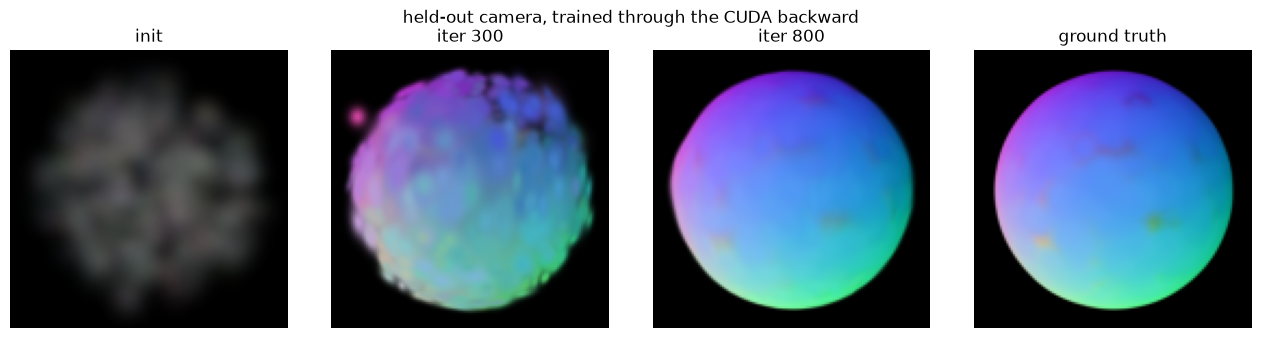

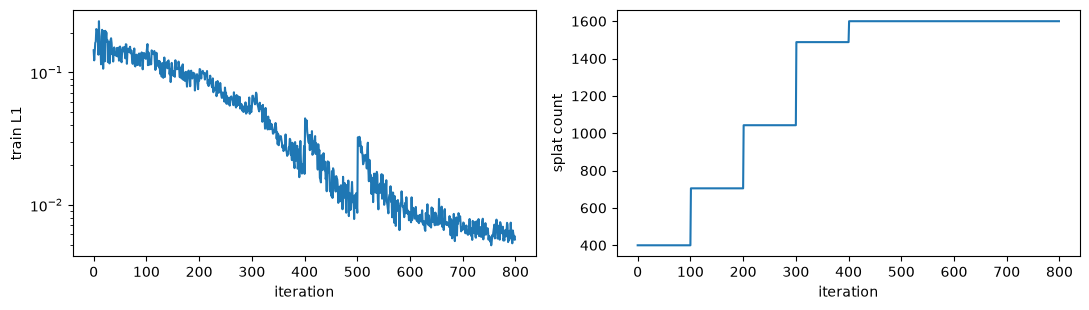

In [6]:
if HAS_GPU:
    gt_means, gt_covs, gt_colors, gt_opac = sphere_shell()

    def orbit_camera(az_deg, el, r=3.0):
        a = np.radians(az_deg)
        eye = r * np.array([np.cos(el) * np.sin(a), np.sin(el),
                            -np.cos(el) * np.cos(a)])
        return Camera.looking_at(eye=eye, target=[0, 0, 0],
                                 fx=FX, fy=FX, H=SIZE, W=SIZE)

    train_cams = [orbit_camera(az, el)
                  for el in (-0.35, 0.0, 0.35) for az in range(0, 360, 45)]
    held_out = orbit_camera(202.5, 0.18)
    gt_images = [torch.tensor(np.clip(render_gaussians(
        c, gt_means, gt_covs, gt_colors, gt_opac)[0], 0, 1),
        dtype=torch.float32, device=DEV) for c in train_cams]
    gt_held = torch.tensor(np.clip(render_gaussians(
        held_out, gt_means, gt_covs, gt_colors, gt_opac)[0], 0, 1),
        dtype=torch.float32, device=DEV)

    K0, K_CAP, ITERS = 400, 1600, 800
    LR = {"means": 1e-3, "log_s": 5e-3, "quats": 1e-3,
          "sh0": 2.5e-3, "o_logit": 5e-2}
    tgen = torch.Generator(device="cpu").manual_seed(12)

    def init_params(k):
        d = torch.randn(k, 3, generator=tgen)
        d = d / d.norm(dim=-1, keepdim=True)
        r = torch.rand(k, 1, generator=tgen) ** (1 / 3)
        mk = lambda t: t.to(DEV).requires_grad_()
        return {
            "means": mk(d * r),
            "log_s": mk(torch.full((k, 3), float(np.log(0.09)))),
            "quats": mk(torch.tensor([[1.0, 0, 0, 0]] * k)
                        + 0.01 * torch.randn(k, 4, generator=tgen)),
            "sh0": mk(0.2 * torch.randn(k, 3, generator=tgen)),
            "o_logit": mk(torch.full((k,), -2.2)),
        }

    class AdamDict:
        def __init__(self, params, lr, b1=0.9, b2=0.999, eps=1e-8):
            self.lr, self.b1, self.b2, self.eps, self.t = lr, b1, b2, eps, 0
            self.m = {k: torch.zeros_like(v) for k, v in params.items()}
            self.v = {k: torch.zeros_like(v) for k, v in params.items()}

        @torch.no_grad()
        def step(self, params):
            self.t += 1
            for k, p in params.items():
                if p.grad is None:
                    continue
                self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * p.grad
                self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * p.grad ** 2
                mhat = self.m[k] / (1 - self.b1 ** self.t)
                vhat = self.v[k] / (1 - self.b2 ** self.t)
                p -= self.lr[k] * mhat / (torch.sqrt(vhat) + self.eps)
                p.grad = None

    GRAD_TAU, PERCENT_DENSE, EXTENT = 2e-4, 0.01, 3.0

    def densify_and_prune(params, opt, accum, count):
        with torch.no_grad():
            opac = torch.sigmoid(params["o_logit"])
            avg = (accum / count.clamp(min=1)) * (SIZE / 2)
            keep = opac >= 0.005
            big = torch.exp(params["log_s"]).max(dim=-1).values \
                > PERCENT_DENSE * EXTENT
            hot = avg > GRAD_TAU
            clone = keep & hot & ~big
            split = keep & hot & big
            keep_after = keep & ~split
            pieces = {k: [v[keep_after]] for k, v in params.items()}
            mstate = {k: [opt.m[k][keep_after]] for k in params}
            vstate = {k: [opt.v[k][keep_after]] for k in params}

            def add(idx, jitter, shrink):
                n = int(idx.sum())
                if n == 0:
                    return 0
                for k, v in params.items():
                    new = v[idx].clone()
                    if k == "means" and jitter:
                        R = quat_to_R_t(params["quats"][idx])
                        s = torch.exp(params["log_s"][idx])
                        eps = torch.randn(n, 3, generator=tgen).to(DEV)
                        new = new + (R @ (s * eps)[..., None])[..., 0]
                    if k == "log_s" and shrink:
                        new = new - float(np.log(1.6))
                    pieces[k].append(new)
                    mstate[k].append(torch.zeros_like(new))
                    vstate[k].append(torch.zeros_like(new))
                return n

            nc = add(clone, jitter=False, shrink=False)
            ns = int(split.sum())
            add(split, jitter=True, shrink=True)
            add(split, jitter=True, shrink=True)
            out = {}
            for k in params:
                cat = torch.cat(pieces[k])[:K_CAP]
                out[k] = cat.clone().requires_grad_()
                opt.m[k] = torch.cat(mstate[k])[:K_CAP]
                opt.v[k] = torch.cat(vstate[k])[:K_CAP]
            return out, nc, ns, int((~keep).sum())

    params = init_params(K0)
    opt = AdamDict(params, LR)

    def render_current(cam, track=False):
        colors = torch.clamp(C0 * params["sh0"] + 0.5, min=0.0)
        return render_kernel(params["means"],
                             cov3d_t(params["log_s"], params["quats"]),
                             colors, torch.sigmoid(params["o_logit"]),
                             cam, track_means2d=track)

    with torch.no_grad():
        init_held = render_current(held_out)[0].clone()

    losses, counts, snaps = [], [], {}
    accum = torch.zeros(K0, device=DEV)
    count = torch.zeros(K0, device=DEV)
    order_gen = np.random.default_rng(12)
    torch.cuda.synchronize()
    t_start = time.perf_counter()

    for it in range(ITERS):
        cam_i = int(order_gen.integers(len(train_cams)))
        img, means2d, vis_idx = render_current(train_cams[cam_i], track=True)
        loss = (img - gt_images[cam_i]).abs().mean()
        loss.backward()
        with torch.no_grad():
            if means2d.grad is not None:
                accum[vis_idx] += means2d.grad.norm(dim=-1)
                count[vis_idx] += 1
        opt.step(params)
        losses.append(float(loss.detach()))
        counts.append(len(params["means"]))
        if it % 100 == 0:
            print(f"iter {it:4d}  L1 {losses[-1]:.4f}  K {counts[-1]}")
        if 100 <= it < 600 and it % 100 == 0:
            params, nc, ns, npr = densify_and_prune(params, opt, accum, count)
            accum = torch.zeros(len(params["means"]), device=DEV)
            count = torch.zeros_like(accum)
            print(f"           densify: +{nc} cloned, +{2 * ns} split, "
                  f"-{npr} pruned -> K={len(params['means'])}")
        if it == 300:
            with torch.no_grad():
                snaps[it] = render_current(held_out)[0].clone()

    torch.cuda.synchronize()
    wall = time.perf_counter() - t_start
    ms_iter = wall / ITERS * 1e3
    K_final = len(params["means"])
    print(f"{ITERS} iters in {wall:.1f} s -> {ms_iter:.1f} ms/iter "
          f"(K grew {K0} -> {K_final})")

    # dense baseline at the splat count training actually reached
    final_cpu = {k: v.detach().cpu().clone().requires_grad_()
                 for k, v in params.items()}

    def dense_step_final():
        img = render_dense(final_cpu["means"],
                           cov3d_t(final_cpu["log_s"], final_cpu["quats"]),
                           torch.clamp(C0 * final_cpu["sh0"] + 0.5, min=0.0),
                           torch.sigmoid(final_cpu["o_logit"]), cam0)
        loss = (img - target_probe).abs().mean()
        loss.backward()
        for p in final_cpu.values():
            p.grad = None

    dense_step_final()
    t0 = time.perf_counter()
    for _ in range(3):
        dense_step_final()
    t_dense_matched = (time.perf_counter() - t0) / 3
    speedup = t_dense_matched * 1e3 / ms_iter
    print(f"dense CPU at K={K_final}: {t_dense_matched * 1e3:.0f} ms/iter; "
          f"kernel training speedup {speedup:.0f}x "
          f"(K=400 probe baseline was {t_dense_cpu * 1e3:.0f} ms/iter)")
    assert speedup >= 10, "kernel training is not 10x the dense baseline"

    with torch.no_grad():
        final_held = render_current(held_out)[0].clone()
    init_l1 = float((init_held - gt_held).abs().mean())
    final_l1 = float((final_held - gt_held).abs().mean())
    print(f"held-out L1: init {init_l1:.4f} -> final {final_l1:.4f}")
    assert final_l1 < 0.3 * init_l1, "quality below notebook 09's bar"

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
    for ax, (im, ttl) in zip(axes, [
            (init_held, "init"), (snaps[300], "iter 300"),
            (final_held, f"iter {ITERS}"), (gt_held, "ground truth")]):
        ax.imshow(np.clip(im.cpu().numpy(), 0, 1))
        ax.axis("off"); ax.set_title(ttl)
    plt.suptitle("held-out camera, trained through the CUDA backward")
    plt.tight_layout(); plt.show()

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.2))
    ax0.semilogy(losses); ax0.set_xlabel("iteration")
    ax0.set_ylabel("train L1")
    ax1.plot(counts); ax1.set_xlabel("iteration")
    ax1.set_ylabel("splat count")
    plt.tight_layout(); plt.show()
else:
    print("skipped: kernel training run (no CUDA device)")
    print("On a CUDA machine this cell trains the toy scene through the")
    print("tiled backward and asserts a >= 10x speedup over the dense")
    print("baseline at matching quality. With a real scene in data/, swap")
    print("the ground truth for captured images and cameras.")

## What this repository now contains

A renderer derived from a failing point cloud (01-05), view-dependent
color (06), real captured scenes (07), gradients earned by hand in 2D
(08), a differentiable 3D pipeline (09), and that same pipeline as CUDA
kernels: forward (10), tiled (11), and now differentiable (12), with
training running at kernel speed against the dense baseline. Every
constant, convention, and clamp along the way is written down in
`docs/DECISIONS.md`, and every formula answered to an assert before it
was trusted.

The one door left deliberately open is phase E: profiling. The speedup
numbers in these three notebooks say the tile design wins; they do not
yet say where the remaining time goes, what occupancy the kernels
reach, or which stage saturates first as scenes grow. Those questions
have measured answers, and nothing new needs to be built to ask them.